# 🎵 Melodies of Migration: Sentiment Analysis
## How War Shaped the Music We Listen To

**Dataset:** 739 songs | 50 artists | 5 countries  
**Countries:** Ukraine, Russia, Israel, Syria, Palestine  
**Method:** VADER Sentiment Analysis  
**Conflict Years:** Ukraine (2022), Russia (2022), Syria (2011), Palestine (2023), Israel (2023)

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load data
with open("lyrics_data/raw_lyrics.json", "r", encoding="utf-8") as f:
    results = json.load(f)

print(f"Total songs: {len(results)}")

# Dataset overview
df_raw = pd.DataFrame(results)
print("\nSongs per country:")
print(df_raw['country'].value_counts())
print("\nArtists per country:")
print(df_raw.groupby('country')['artist'].nunique())

Total songs: 739

Songs per country:
country
Israel       189
Ukraine      175
Russia       157
Syria        111
Palestine    107
Name: count, dtype: int64

Artists per country:
country
Israel       10
Palestine    10
Russia       10
Syria        10
Ukraine      10
Name: artist, dtype: int64


In [3]:
CONFLICT_YEARS = {
    "Ukraine": 2022,
    "Russia": 2022,
    "Syria": 2011,
    "Palestine": 2023,
    "Israel": 2023,
}

analyzer = SentimentIntensityAnalyzer()

for item in results:
    scores = analyzer.polarity_scores(item['lyrics'])
    item['compound'] = scores['compound']
    conflict_year = CONFLICT_YEARS.get(item['country'], 2022)
    try:
        year = int(str(item['year'])[:4]) if item['year'] else None
        item['period'] = 'pre' if year and year < conflict_year else 'post'
        item['year_int'] = year
    except:
        item['period'] = 'unknown'
        item['year_int'] = None

df = pd.DataFrame(results)
print("Sentiment analysis complete!")
print(df[['country', 'compound', 'period']].head(10))

Sentiment analysis complete!
   country  compound period
0  Ukraine    0.9686    pre
1  Ukraine    0.0000    pre
2  Ukraine    0.0000    pre
3  Ukraine    0.0000    pre
4  Ukraine   -0.2977    pre
5  Ukraine    0.0000    pre
6  Ukraine    0.9977    pre
7  Ukraine    0.9527    pre
8  Ukraine    0.0000   post
9  Ukraine    0.0000    pre


## 📊 Overall Sentiment by Country

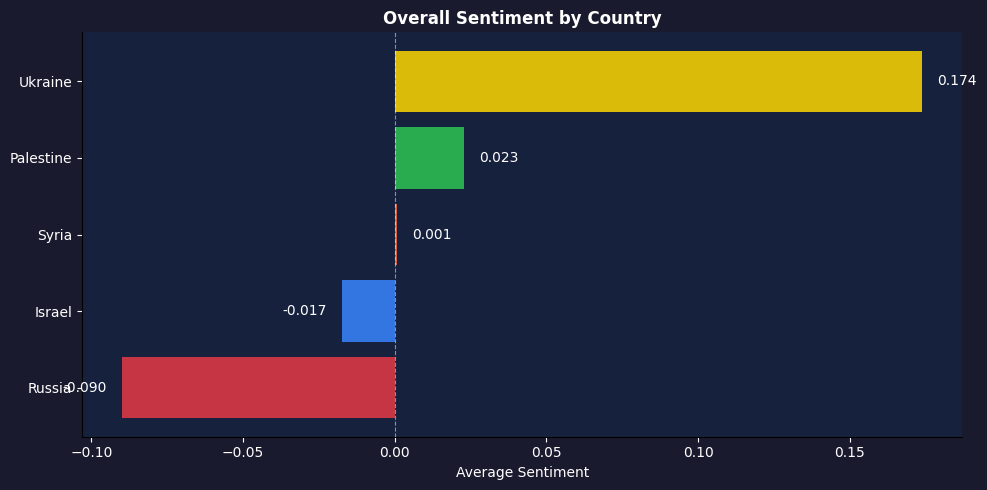

In [4]:
country_colors = {
    'Ukraine': '#FFD700', 'Russia': '#E63946',
    'Israel': '#3A86FF', 'Syria': '#FF6B35', 'Palestine': '#2DC653'
}

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

sentiment = df.groupby('country')['compound'].mean().sort_values()
colors = [country_colors.get(c, '#888') for c in sentiment.index]
bars = ax.barh(sentiment.index, sentiment.values, color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Average Sentiment', color='white')
ax.set_title('Overall Sentiment by Country', color='white', fontweight='bold')
ax.tick_params(colors='white')
for bar, val in zip(bars, sentiment.values):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right',
            color='white', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lyrics_data/sentiment_analysis.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## ⚔️ Pre vs Post Conflict Sentiment Change
This chart shows how the emotional tone of music changed after conflict began.

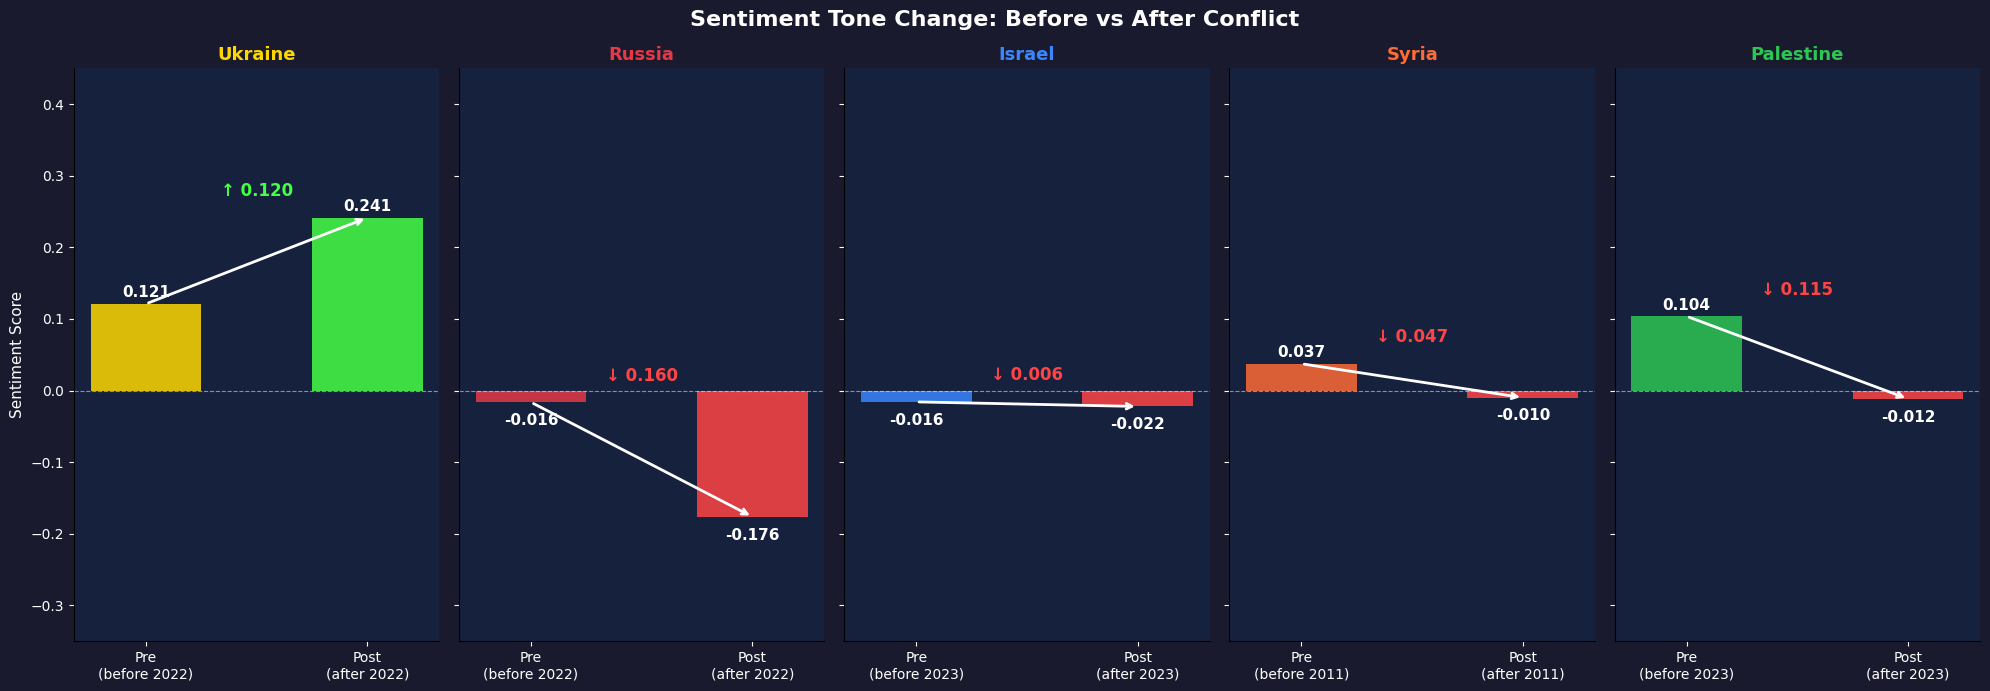

In [5]:
countries = ['Ukraine', 'Russia', 'Israel', 'Syria', 'Palestine']

fig, axes = plt.subplots(1, 5, figsize=(20, 7), sharey=True)
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Sentiment Tone Change: Before vs After Conflict', 
             color='white', fontsize=16, fontweight='bold')

for idx, country in enumerate(countries):
    ax = axes[idx]
    ax.set_facecolor('#16213e')
    
    country_df = df[(df['country'] == country) & (df['period'].isin(['pre', 'post']))]
    pre = country_df[country_df['period'] == 'pre']['compound'].mean()
    post = country_df[country_df['period'] == 'post']['compound'].mean()
    
    color = country_colors[country]
    conflict_year = CONFLICT_YEARS[country]
    
    bars = ax.bar(['Pre\n(before {})'.format(conflict_year), 
                   'Post\n(after {})'.format(conflict_year)], 
                  [pre, post], 
                  color=[color, '#ff4444' if post < pre else '#44ff44'],
                  alpha=0.85, width=0.5)
    
    for bar, val in zip(bars, [pre, post]):
        ax.text(bar.get_x() + bar.get_width()/2, 
                val + 0.005 if val >= 0 else val - 0.015,
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                color='white', fontsize=11, fontweight='bold')
    
    ax.annotate('', xy=(1, post), xytext=(0, pre),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    
    change = post - pre
    ax.text(0.5, max(pre, post) + 0.03, 
            f'{"↑" if change > 0 else "↓"} {abs(change):.3f}',
            ha='center', color='#44ff44' if change > 0 else '#ff4444',
            fontsize=12, fontweight='bold', transform=ax.transData)
    
    ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(country, color=color, fontsize=13, fontweight='bold')
    ax.tick_params(colors='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(-0.35, 0.45)

axes[0].set_ylabel('Sentiment Score', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('lyrics_data/prepost_conflict.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 📈 Sentiment Over Time
Dashed vertical lines indicate conflict start years.

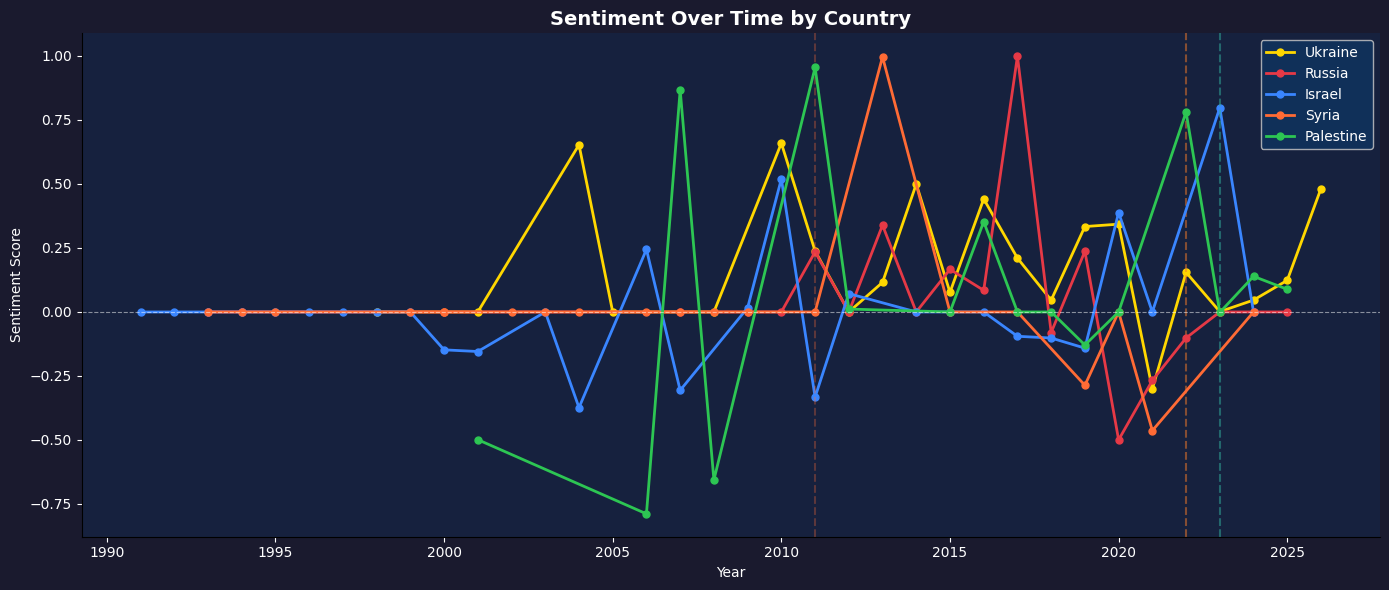

In [6]:
df_year = df[df['year_int'].notna() & (df['year_int'] > 1990) & (df['year_int'] <= 2026)]
df_year['year_int'] = df_year['year_int'].astype(int)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for country, color in country_colors.items():
    country_df = df_year[df_year['country'] == country]
    if not country_df.empty:
        yearly = country_df.groupby('year_int')['compound'].mean()
        ax.plot(yearly.index, yearly.values, marker='o', label=country, 
                color=color, linewidth=2, markersize=5)
        conflict_year = CONFLICT_YEARS[country]
        ax.axvline(conflict_year, color=color, linestyle='--', alpha=0.3)

ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Year', color='white')
ax.set_ylabel('Sentiment Score', color='white')
ax.set_title('Sentiment Over Time by Country', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#0f3460', labelcolor='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lyrics_data/sentiment_over_time.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 🎵 Top Positive & Negative Songs
### Top Songs
- `df.nlargest(5, 'compound')` → 5 songs closest to +1 (most positive)
- `df.nsmallest(5, 'compound')` → 5 songs closest to -1 (most negative)

In [7]:
print("=== TOP 5 MOST POSITIVE SONGS ===")
top_positive = df.nlargest(5, 'compound')[['artist', 'country', 'song_title', 'compound', 'year_int']]
print(top_positive.to_string(index=False))

print("\n=== TOP 5 MOST NEGATIVE SONGS ===")
top_negative = df.nsmallest(5, 'compound')[['artist', 'country', 'song_title', 'compound', 'year_int']]
print(top_negative.to_string(index=False))

=== TOP 5 MOST POSITIVE SONGS ===
           artist   country                                                song_title  compound  year_int
              DAM Palestine         Mama, I Fell in Love with a Jew - وقعت بحب يهوديه    0.9998    2012.0
           Jamala   Ukraine                                                 Thank You    0.9994    2014.0
Khrystyna Soloviy   Ukraine Forest song (Original Soundtrack «Mavka. The Forest Song)    0.9994    2023.0
       Pussy Riot    Russia                                              Police State    0.9991    2017.0
       Oxxxymiron    Russia                           Девочка Пиздец (Fucked Up Girl)    0.9989    2015.0

=== TOP 5 MOST NEGATIVE SONGS ===
       artist country       song_title  compound  year_int
          DDT  Russia  Blue Hair Crime   -0.9997       NaN
      IC3PEAK  Russia            TRRST   -0.9997       NaN
      Boombox Ukraine Fatal Attraction   -0.9990    2021.0
   Pussy Riot  Russia         HATEFUCK   -0.9985    2022.0
